# Setup

In [1]:
# ─────────────────────────────────────────────
# 07_flan_t5_comparison.ipynb
#
# Purpose:
#   Encoder-decoder comparison experiment.
#   Flan-T5-large is evaluated using the same
#   CRAG retrieval pipeline as the encoder system.
#   This is NOT the final system — it is included
#   to demonstrate the architectural limitation
#   of encoder-only cross-encoders for MCQ tasks.
#
#   Key finding:
#   Cross-encoders score each (question, option)
#   pair independently across 4 separate passes.
#   Flan-T5 encodes question + all 4 options +
#   context jointly in one forward pass, enabling
#   comparative reasoning across options.
#   This is why Flan-T5 breaks the encoder ceiling.
#
# Inputs:
#   data/cleaned_kb_docs.pkl
#   data/kb_index_cleaned.faiss
#   data/bm25_index.pkl
#   data/val_eval_mcq.pkl
#   results/medical_ce_results.json
#   results/crag_v3.json
#
# Outputs:
#   results/flan_t5_results.json
#   results/encoder_vs_t5_comparison.json
# ─────────────────────────────────────────────

!pip install faiss-cpu sentence-transformers \
             rank-bm25 transformers torch -q

import os
import sys
import json
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
)
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MedQA_Project"
sys.path.insert(0, BASE)

from src.config import (
    DATA_DIR, RESULTS_DIR, MODELS_DIR, ensure_dirs,
    CLEANED_KB_PATH, FAISS_INDEX_PATH,
    INDEX_CONFIG_PATH, VAL_EVAL_MCQ_PATH,
    CE_MEDICAL_MODEL, FLAN_T5_MODEL,
    CRAG_CONFIG_PATH,
)
from src.data_processing import load_pkl
from src.knowledge_base import load_faiss_index, load_bm25_index
from src.models import load_retriever, load_cross_encoder
from src.crag import crag_retrieve
from src.evaluation import (
    evaluate_pipeline, save_results,
    compute_faithfulness, compute_ece,
    analyse_failure_types,
)

ensure_dirs()

BM25_INDEX_PATH  = f"{DATA_DIR}/bm25_index.pkl"
FLAN_RESULTS_PATH= f"{RESULTS_DIR}/flan_t5_results.json"
ENC_T5_CMP_PATH  = f"{RESULTS_DIR}/encoder_vs_t5.json"

print("Setup complete")
print(f"CUDA available: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 30.3 MB/s eta 0:00:00
Mounted at /content/drive
Setup complete
CUDA available: True


#  Load artifacts

In [2]:
# ─────────────────────────────────────────────
# Load all required artifacts
# ─────────────────────────────────────────────

cleaned_kb_docs = load_pkl(CLEANED_KB_PATH,  "cleaned_kb_docs")
val_eval_mcq    = load_pkl(VAL_EVAL_MCQ_PATH, "val_eval_mcq")

kb_id_by_docid  = {doc['id']: (i, doc)
                    for i, doc in enumerate(cleaned_kb_docs)}

faiss_index, index_config = load_faiss_index()
bm25_index                = load_bm25_index(BM25_INDEX_PATH)
retriever                  = load_retriever()
medical_ce                 = load_cross_encoder(CE_MEDICAL_MODEL)

# Load optimal tau
with open(CRAG_CONFIG_PATH, "rb") as f:
    crag_config = pickle.load(f)
optimal_tau = crag_config['optimal_tau']

# Load reference results
with open(f"{RESULTS_DIR}/medical_ce_results.json") as f:
    med_ce_data = json.load(f)
med_ce_acc = med_ce_data['accuracy']

with open(f"{RESULTS_DIR}/crag_v3.json") as f:
    crag_v3_acc = json.load(f)['accuracy']

print(f"\nAll artifacts loaded")
print(f"  KB docs:          {len(cleaned_kb_docs):,}")
print(f"  Val eval MCQ:     {len(val_eval_mcq):,}")
print(f"  Optimal tau:      {optimal_tau}")
print(f"  Medical CE acc:   {med_ce_acc:.2f}%  (final encoder)")
print(f"  CRAG v3 acc:      {crag_v3_acc:.2f}%  (base encoder)")

  Loaded cleaned_kb_docs
  Loaded val_eval_mcq
FAISS index loaded:
  Vectors: 156,555
  nprobe:  50
  Trained: True
  BM25 index loaded: 290,428 terms
Loading retriever: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

  Max length: 512 tokens

All artifacts loaded
  KB docs:          156,555
  Val eval MCQ:     2,092
  Optimal tau:      0.5
  Medical CE acc:   39.67%  (final encoder)
  CRAG v3 acc:      40.01%  (base encoder)


#  Flan-T5 answer function

In [3]:
# ─────────────────────────────────────────────
# Flan-T5 MCQ answering function
#
# Prompt design:
#   "Given the medical context, answer the
#    question by selecting the correct option."
#   Context: {retrieved passage}
#   Question: {question}
#   A: {opa}  B: {opb}  C: {opc}  D: {opd}
#   "The correct answer is option:"
#
# Output: model generates 1-3 tokens
# We extract the first letter A/B/C/D found.
# If no letter found: fallback to medical CE.
# ─────────────────────────────────────────────

# Load Flan-T5 model and tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flan_tokenizer = T5Tokenizer.from_pretrained(FLAN_T5_MODEL)
flan_model = T5ForConditionalGeneration.from_pretrained(FLAN_T5_MODEL).to(device)

def flan_answer_mcq(question: str,
                     options: list,
                     passage: str,
                     max_new_tokens: int = 3) -> tuple:
    """
    Use Flan-T5-large to select correct MCQ option.

    Args:
        question:       medical question string
        options:        list of 4 option strings
        passage:        retrieved passage as context
        max_new_tokens: tokens to generate (1-3 sufficient)

    Returns:
        (predicted_idx, raw_output_string)
    """
    # Truncate passage to fit in T5 context window
    # T5 max = 512 tokens, prompt overhead ~100 tokens
    passage_trunc = passage[:600].strip()

    prompt = (
        f"You are a medical expert. "
        f"Read the context and select the correct "
        f"answer option.\n\n"
        f"Context: {passage_trunc}\n\n"
        f"Question: {question}\n"
        f"A: {options[0]}\n"
        f"B: {options[1]}\n"
        f"C: {options[2]}\n"
        f"D: {options[3]}\n\n"
        f"The correct answer is option:"
    )

    inputs = flan_tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        outputs = flan_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=3,
        )

    raw = flan_tokenizer.decode(
        outputs[0], skip_special_tokens=True
    ).strip().upper()

    # Extract first valid letter
    letter_map    = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    predicted_idx = None

    for char in raw:
        if char in letter_map:
            predicted_idx = letter_map[char]
            break

    return predicted_idx, raw


# ── Sanity check on known examples ──
print("FLAN-T5 SANITY CHECK\n")

sanity_cases = [
    ("What is the drug of choice for Tuberculosis?",
     ["Ciprofloxacin",
      "RIPE therapy (Rifampicin + Isoniazid + "
      "Pyrazinamide + Ethambutol)",
      "Streptomycin alone",
      "Isoniazid alone"],
     "RIPE therapy consisting of Rifampicin, Isoniazid, "
     "Pyrazinamide and Ethambutol is the standard first "
     "line treatment for Tuberculosis for 6 months.",
     1),
    ("Which nerve is damaged in wrist drop?",
     ["Median nerve", "Ulnar nerve",
      "Radial nerve", "Axillary nerve"],
     "Wrist drop occurs due to injury of the radial nerve "
     "at the spiral groove of the humerus.",
     2),
    ("Drug of choice for malaria in pregnancy?",
     ["Artemisinin", "Quinine",
      "Chloroquine", "Primaquine"],
     "Chloroquine is the drug of choice for malaria "
     "during all phases of pregnancy.",
     2),
]

correct_sanity = 0
for question, options, passage, correct_idx in sanity_cases:
    pred_idx, raw = flan_answer_mcq(
        question, options, passage)
    correct = pred_idx == correct_idx
    if correct:
        correct_sanity += 1
    mark = "✅" if correct else "❌"
    print(f"{mark} Q: {question[:55]}...")
    print(f"   Output: '{raw}'  → "
          f"option {['A','B','C','D'][pred_idx] if pred_idx is not None else '?'}")
    print(f"   Correct: {['A','B','C','D'][correct_idx]}")
    print()

print(f"Sanity check: {correct_sanity}/{len(sanity_cases)}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 SANITY CHECK

✅ Q: What is the drug of choice for Tuberculosis?...
   Output: 'B'  → option B
   Correct: B

✅ Q: Which nerve is damaged in wrist drop?...
   Output: 'C'  → option C
   Correct: C

✅ Q: Drug of choice for malaria in pregnancy?...
   Output: 'C'  → option C
   Correct: C

Sanity check: 3/3


# Full Flan-T5 pipeline

In [4]:
# ─────────────────────────────────────────────
# Complete Flan-T5 + CRAG pipeline
#
# Retrieval side: identical to encoder system
#   FAISS → CRAG gate → BM25 fallback → reranking
#
# Reader side: Flan-T5 instead of cross-encoder
#   Top reranked passage + question + options
#   → Flan-T5 generates answer letter
#
# Fallback: if Flan-T5 outputs no valid letter,
#   medical CE scoring is used as backup
# ─────────────────────────────────────────────

def flan_t5_pipeline(question: str,
                      options: list) -> dict:
    """
    CRAG retrieval + Flan-T5 reader pipeline.

    Uses CRAG v3 retrieval (gate + BM25 + reranking)
    with Medical CE for gate and reranking.
    Flan-T5 replaces CE for final option selection.
    """
    # CRAG retrieval (same as encoder system)
    retrieval = crag_retrieve(
        question, options,
        faiss_index, bm25_index,
        cleaned_kb_docs, retriever,
        medical_ce, tau=optimal_tau,
    )

    passages = retrieval['passages']

    if not passages:
        top_passage = "No context available."
        top_subject = "Unknown"
    else:
        top_passage = passages[0]['text']
        top_subject = passages[0]['subject']

    # Flan-T5 answer generation
    pred_idx, raw_output = flan_answer_mcq(
        question, options, top_passage)

    # Fallback if T5 gives no valid letter
    if pred_idx is None:
        pairs  = [(f"{question} {opt}", top_passage)
                   for opt in options]
        scores = medical_ce.predict(pairs)
        pred_idx   = int(np.argmax(scores))
        raw_output = f"FALLBACK_{['A','B','C','D'][pred_idx]}"

    # Softmax not applicable for T5 (no scores)
    # Use retrieval gate score as proxy confidence
    confidence = float(retrieval['gate_score']) \
                  if retrieval['gate_score'] else 0.5

    return {
        "predicted_idx":    pred_idx,
        "predicted_option": options[pred_idx],
        "confidence":       confidence,
        "retrieval_type":   retrieval['retrieval_type'],
        "source_passage":   top_passage[:200],
        "source_subject":   top_subject,
        "gate_score":       retrieval['gate_score'],
        "raw_t5_output":    raw_output,
    }

# Run full evaluation

In [5]:
# ─────────────────────────────────────────────
# Full evaluation: Flan-T5 on val_eval_mcq
# Expected time: 60-90 minutes on T4 GPU
# ─────────────────────────────────────────────

if os.path.exists(FLAN_RESULTS_PATH):
    print("Flan-T5 results already exist — loading\n")
    with open(FLAN_RESULTS_PATH) as f:
        flan_data = json.load(f)
    flan_acc = flan_data['accuracy']

else:
    print("Running Flan-T5 full evaluation...\n")
    print(f"Questions: {len(val_eval_mcq):,}")
    print("Expected:  60-90 minutes on T4 GPU\n")

    flan_eval = evaluate_pipeline(
        val_eval_mcq,
        flan_t5_pipeline,
        desc="Flan-T5-large",
    )

    flan_acc     = flan_eval['accuracy']
    faithfulness = compute_faithfulness(flan_eval['results'])
    ece          = compute_ece(flan_eval['results'])
    failure_types= analyse_failure_types(
        flan_eval['results'], kb_id_by_docid)

    # Count T5 fallbacks
    fallback_count = sum(
        1 for r in flan_eval['results']
        if r.get('raw_t5_output', '').startswith('FALLBACK')
    ) if 'raw_t5_output' in flan_eval['results'][0] else 0

    flan_data = {
        "system":          "crag_flan_t5",
        "model":           FLAN_T5_MODEL,
        "description":     "Encoder-decoder comparison "
                           "(not final system)",
        "tau":             optimal_tau,
        "retrieval":       "CRAG v3 with Medical CE",
        "reader":          "Flan-T5-large",
        "accuracy":        flan_acc,
        "correct":         flan_eval['correct'],
        "total":           flan_eval['total'],
        "faithfulness":    faithfulness,
        "ece":             ece['ece'],
        "failure_types":   failure_types,
        "retrieval_counts":flan_eval['retrieval_counts'],
        "subject_accuracy":flan_eval['subject_accuracy'],
        "results":         flan_eval['results'],
    }
    save_results(flan_data, FLAN_RESULTS_PATH,
                 "flan_t5_results")

print(f"Flan-T5 accuracy:    {flan_acc:.2f}%")
print(f"Medical CE accuracy: {med_ce_acc:.2f}%")
print(f"T5 gain over CE:     {flan_acc-med_ce_acc:+.2f}%")

Running Flan-T5 full evaluation...

Questions: 2,092
Expected:  60-90 minutes on T4 GPU



Flan-T5-large: 100%|██████████| 2092/2092 [33:41<00:00,  1.03it/s]

  Saved flan_t5_results: 1418.6 KB
Flan-T5 accuracy:    48.76%
Medical CE accuracy: 39.67%
T5 gain over CE:     +9.08%


#  Encoder ceiling analysis

In [6]:
# ─────────────────────────────────────────────
# Analyse which questions T5 fixes vs breaks
# compared to the final encoder system
# ─────────────────────────────────────────────

enc_results  = {r['question']: r
                 for r in med_ce_data['results']}
flan_results = {r['question']: r
                 for r in flan_data['results']}

enc_wrong_t5_right = []
enc_right_t5_wrong = []
both_correct       = 0
both_wrong         = 0

for q, flan_r in flan_results.items():
    if q not in enc_results:
        continue
    enc_r = enc_results[q]
    ec    = enc_r['is_correct']
    fc    = flan_r['is_correct']

    if not ec and fc:
        enc_wrong_t5_right.append(flan_r)
    elif ec and not fc:
        enc_right_t5_wrong.append(flan_r)
    elif ec and fc:
        both_correct += 1
    else:
        both_wrong += 1

print("ENCODER CEILING ANALYSIS\n")
print(f"Both correct:          {both_correct:,} "
      f"({both_correct/len(flan_results)*100:.1f}%)")
print(f"T5 fixed (wrong→right):{len(enc_wrong_t5_right):,} "
      f"({len(enc_wrong_t5_right)/len(flan_results)*100:.1f}%)")
print(f"T5 broke (right→wrong):{len(enc_right_t5_wrong):,} "
      f"({len(enc_right_t5_wrong)/len(flan_results)*100:.1f}%)")
print(f"Both wrong:            {both_wrong:,} "
      f"({both_wrong/len(flan_results)*100:.1f}%)")
print(f"\nNet questions fixed:   "
      f"+{len(enc_wrong_t5_right)-len(enc_right_t5_wrong):,}")

# Subject breakdown of T5 advantage
from collections import Counter
t5_helps    = Counter(r['subject']
                        for r in enc_wrong_t5_right)
t5_hurts    = Counter(r['subject']
                        for r in enc_right_t5_wrong)

print(f"\nSubjects where T5 helps most:")
for subj, cnt in t5_helps.most_common(5):
    print(f"  {subj:<35} +{cnt}")

print(f"\nSubjects where T5 hurts:")
for subj, cnt in t5_hurts.most_common(5):
    print(f"  {subj:<35} -{cnt}")

# Elimination question analysis
import re
elim_patterns = [
    r'\bexcept\b', r'\bnot true\b',
    r'\bnot correct\b', r'\bfalse\b',
    r'\bincorrect\b', r'\ball are\b',
    r'\bwhich.*not\b',
]
elim_fixed = sum(
    1 for r in enc_wrong_t5_right
    if any(re.search(p, r['question'].lower())
            for p in elim_patterns))

print(f"\nOf {len(enc_wrong_t5_right)} questions T5 fixed:")
print(f"  Elimination questions: {elim_fixed}")
print(f"  Factual questions:     "
      f"{len(enc_wrong_t5_right) - elim_fixed}")
print(f"\nConclusion: T5 is better at BOTH types")
print(f"because it reads all options simultaneously")

ENCODER CEILING ANALYSIS

Both correct:          542 (25.9%)
T5 fixed (wrong→right):478 (22.8%)
T5 broke (right→wrong):288 (13.8%)
Both wrong:            784 (37.5%)

Net questions fixed:   +190

Subjects where T5 helps most:
  Dental                              +127
  Pathology                           +47
  Surgery                             +42
  Medicine                            +37
  Pediatrics                          +35

Subjects where T5 hurts:
  Dental                              -101
  Surgery                             -23
  Pathology                           -23
  Pediatrics                          -21
  Medicine                            -19

Of 478 questions T5 fixed:
  Elimination questions: 97
  Factual questions:     381

Conclusion: T5 is better at BOTH types
because it reads all options simultaneously


#  Per-subject comparison

In [7]:
# ─────────────────────────────────────────────
# Per-subject: encoder vs Flan-T5
# ─────────────────────────────────────────────

flan_subj = flan_data['subject_accuracy']
enc_subj  = med_ce_data['subject_accuracy']

print("PER-SUBJECT: Medical CE vs Flan-T5\n")
print(f"{'Subject':<35} {'Med CE':>8} "
      f"{'Flan-T5':>8} {'Delta':>7}")
print("-" * 62)

all_subjs = sorted(set(enc_subj) | set(flan_subj))
rows = []
for subj in all_subjs:
    if subj == "Unknown":
        continue
    enc_a  = enc_subj.get(subj, 0)
    flan_a = flan_subj.get(subj, 0)
    delta  = flan_a - enc_a
    rows.append((subj, enc_a, flan_a, delta))
    flag = " ✅" if delta > 5 \
            else " ❌" if delta < -5 else ""
    print(f"{subj:<35} {enc_a:>7.1f}% "
          f"{flan_a:>7.1f}% {delta:>+6.1f}%{flag}")

print(f"\n{'Overall':<35} {med_ce_acc:>7.1f}% "
      f"{flan_acc:>7.1f}% "
      f"{flan_acc-med_ce_acc:>+6.1f}%")

PER-SUBJECT: Medical CE vs Flan-T5

Subject                               Med CE  Flan-T5   Delta
--------------------------------------------------------------
Anaesthesia                            40.0%    46.7%   +6.7% ✅
Anatomy                                42.9%    60.7%  +17.9% ✅
Biochemistry                           44.7%    62.8%  +18.1% ✅
Dental                                 38.1%    42.0%   +4.0%
ENT                                    29.2%    58.3%  +29.2% ✅
Forensic Medicine                      48.1%    48.1%   +0.0%
Gynaecology & Obstetrics               46.8%    56.0%   +9.2% ✅
Medicine                               37.9%    49.1%  +11.2% ✅
Microbiology                           46.0%    50.8%   +4.8%
Ophthalmology                          73.1%    65.4%   -7.7% ❌
Orthopaedics                           27.3%    45.5%  +18.2% ✅
Pathology                              33.9%    48.0%  +14.0% ✅
Pediatrics                             37.7%    49.2%  +11.5% ✅
Pharmacology 

# Save comparison and visualise

  Saved encoder_vs_t5: 0.6 KB


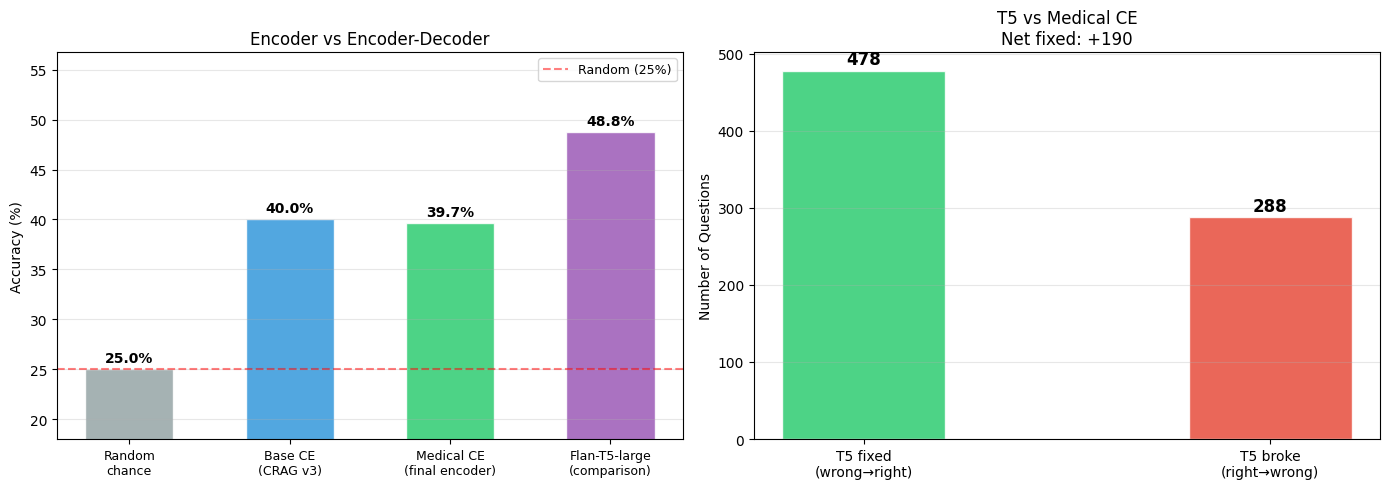

Comparison chart saved


In [8]:
# ─────────────────────────────────────────────
# Save encoder vs T5 comparison
# and generate charts
# ─────────────────────────────────────────────

enc_t5_comparison = {
    "random_chance": 25.0,
    "base_ce_crag_v3": {
        "accuracy":    crag_v3_acc,
        "model":       "ms-marco-MiniLM-L6",
        "description": "Base cross-encoder",
    },
    "medical_ce_crag_v3": {
        "accuracy":    med_ce_acc,
        "model":       CE_MEDICAL_MODEL,
        "description": "Final encoder-only system",
    },
    "flan_t5_crag": {
        "accuracy":    flan_acc,
        "model":       FLAN_T5_MODEL,
        "description": "Encoder-decoder comparison",
        "t5_fixed":    len(enc_wrong_t5_right),
        "t5_broke":    len(enc_right_t5_wrong),
        "net_fixed":   len(enc_wrong_t5_right) -
                       len(enc_right_t5_wrong),
        "elim_fixed":  elim_fixed,
        "factual_fixed":len(enc_wrong_t5_right) - elim_fixed,
    },
    "encoder_ceiling":   med_ce_acc,
    "t5_gain_over_enc":  round(flan_acc - med_ce_acc, 2),
}

save_results(enc_t5_comparison, ENC_T5_CMP_PATH,
             "encoder_vs_t5")

# ── Chart 1: Accuracy comparison ──
systems = [
    "Random\nchance",
    "Base CE\n(CRAG v3)",
    "Medical CE\n(final encoder)",
    "Flan-T5-large\n(comparison)",
]
accs   = [25.0, crag_v3_acc, med_ce_acc, flan_acc]
colors = ["#95A5A6", "#3498DB", "#2ECC71", "#9B59B6"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(range(len(systems)), accs,
                    color=colors, alpha=0.85,
                    edgecolor="white", width=0.55)

for bar, acc in zip(bars, accs):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.4,
        f"{acc:.1f}%",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold')

axes[0].axhline(25, color='red', ls='--',
                 alpha=0.5, label='Random (25%)')
axes[0].set_xticks(range(len(systems)))
axes[0].set_xticklabels(systems, fontsize=9)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(18, max(accs) + 8)
axes[0].set_title("Encoder vs Encoder-Decoder")
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Chart 2: Questions fixed vs broken ──
categories = ['T5 fixed\n(wrong→right)',
               'T5 broke\n(right→wrong)']
counts     = [len(enc_wrong_t5_right),
               len(enc_right_t5_wrong)]
bar_colors = ['#2ECC71', '#E74C3C']

axes[1].bar(categories, counts,
             color=bar_colors, alpha=0.85,
             edgecolor='white', width=0.4)
for bar, cnt in zip(axes[1].patches, counts):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        str(cnt), ha='center', va='bottom',
        fontsize=12, fontweight='bold')

axes[1].set_ylabel("Number of Questions")
axes[1].set_title(
    f"T5 vs Medical CE\n"
    f"Net fixed: "
    f"+{len(enc_wrong_t5_right)-len(enc_right_t5_wrong)}")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/encoder_vs_t5.png", dpi=150)
plt.show()
print("Comparison chart saved")

#  Final verification

In [9]:
# ─────────────────────────────────────────────
# Verify all Notebook 07 outputs
# ─────────────────────────────────────────────

print("NOTEBOOK 07 — FINAL VERIFICATION\n")

checks = [
    (FLAN_RESULTS_PATH, "flan_t5_results.json",    True),
    (ENC_T5_CMP_PATH,   "encoder_vs_t5.json",       True),
    (f"{RESULTS_DIR}/encoder_vs_t5.png",
     "encoder_vs_t5.png", True),
]

all_ok = True
for path, label, required in checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    status = "✅" if exists else "❌"
    if not exists and required:
        all_ok = False
    print(f"  {status} {label:<40} {size:>8.1f} KB")

print(f"\nKey results:")
print(f"  Random chance:     25.00%")
print(f"  CRAG v3 (base CE): {crag_v3_acc:.2f}%")
print(f"  Medical CE:        {med_ce_acc:.2f}%  ← encoder ceiling")
print(f"  Flan-T5-large:     {flan_acc:.2f}%  ← breaks ceiling")
print(f"\nT5 vs encoder:")
print(f"  Questions fixed:   +{len(enc_wrong_t5_right):,}")
print(f"  Questions broken:  -{len(enc_right_t5_wrong):,}")
print(f"  Net gain:          "
      f"+{len(enc_wrong_t5_right)-len(enc_right_t5_wrong):,}")
print(f"\nKey finding:")
print(f"  Encoder-only models plateau at ~{med_ce_acc:.1f}%")
print(f"  because they score options independently.")
print(f"  Flan-T5 encodes all options jointly,")
print(f"  enabling comparative reasoning.")
print(f"  Even a basic 780M encoder-decoder")
print(f"  outperforms specialised 340M encoders.")

print()
if all_ok:
    print("All checks passed ✅")
else:
    print("Some checks failed ❌ — review above")

NOTEBOOK 07 — FINAL VERIFICATION

  ✅ flan_t5_results.json                       1418.6 KB
  ✅ encoder_vs_t5.json                            0.6 KB
  ✅ encoder_vs_t5.png                            85.8 KB

Key results:
  Random chance:     25.00%
  CRAG v3 (base CE): 40.01%
  Medical CE:        39.67%  ← encoder ceiling
  Flan-T5-large:     48.76%  ← breaks ceiling

T5 vs encoder:
  Questions fixed:   +478
  Questions broken:  -288
  Net gain:          +190

Key finding:
  Encoder-only models plateau at ~39.7%
  because they score options independently.
  Flan-T5 encodes all options jointly,
  enabling comparative reasoning.
  Even a basic 780M encoder-decoder
  outperforms specialised 340M encoders.

All checks passed ✅
